# TEP Baseline Models — Isolation Forest & Random Forest

**Maryam Ali · 202509001 · MSc Artificial Intelligence, Bahrain Polytechnic**

This notebook trains and evaluates the two baseline models reported in the Mid-Review
Progress Report: Isolation Forest (unsupervised) and Random Forest (supervised).

**Depends on:** `TEP_Preprocessing.ipynb` — run that first to generate the `.npy` arrays
loaded below. The LSTM Autoencoder and SHAP explainability are implemented separately,
scheduled for Week 7 onward per the project Gantt chart.

**Status:** ✅ Isolation Forest · ✅ Random Forest · ⬜ LSTM Autoencoder · ⬜ SHAP

## 1 · Load Preprocessed Data

Loads the arrays saved by `TEP_Preprocessing.ipynb` — no need to reload or reprocess
the raw TEP files here.

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, roc_auc_score,
)
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

SEED = 42
TEAL, PURPLE = "#0F6E56", "#5B54C0"

X_train_s      = np.load("csv/X_train_scaled.npy")
X_test_s       = np.load("csv/X_test_scaled.npy")
y_train        = np.load("csv/y_train.npy")
y_test         = np.load("csv/y_test.npy")
X_train_normal = np.load("csv/X_train_normal_only.npy")

print(f"Train: {X_train_s.shape} · Test: {X_test_s.shape}")
print(f"Normal-only training subset (for Isolation Forest): {X_train_normal.shape}")

Train: (385000, 52) · Test: (165000, 52)
Normal-only training subset (for Isolation Forest): (175000, 52)


## 2 · Isolation Forest (Unsupervised)

Trained on normal operation data only — no fault labels used during training.

In [2]:
iso = IsolationForest(n_estimators=200, contamination="auto", random_state=SEED, n_jobs=-1)
iso.fit(X_train_normal)

iso_scores = -iso.score_samples(X_test_s)
iso_pred   = (iso.predict(X_test_s) == -1).astype(int)

iso_metrics = {
    "Precision": precision_score(y_test, iso_pred),
    "Recall":    recall_score(y_test, iso_pred),
    "F1":        f1_score(y_test, iso_pred),
    "ROC-AUC":   roc_auc_score(y_test, iso_scores),
}

print("=== Isolation Forest — Test Set Results ===")
print(classification_report(y_test, iso_pred, target_names=["Normal", "Fault"], digits=3))
print(f"ROC-AUC: {iso_metrics['ROC-AUC']:.3f}")

=== Isolation Forest — Test Set Results ===
              precision    recall  f1-score   support

      Normal      0.575     0.983     0.726     75000
       Fault      0.966     0.394     0.559     90000

    accuracy                          0.662    165000
   macro avg      0.770     0.689     0.642    165000
weighted avg      0.788     0.662     0.635    165000

ROC-AUC: 0.764


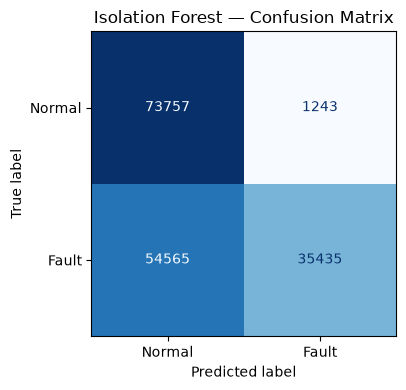

In [3]:
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, iso_pred, display_labels=["Normal", "Fault"],
    cmap="Blues", colorbar=False, ax=ax)
ax.set_title("Isolation Forest — Confusion Matrix")
plt.tight_layout(); plt.savefig("figures/iso_confusion_matrix.png", bbox_inches="tight"); plt.show()

## 3 · Random Forest (Supervised)

Trained with full fault labels, class-weight balanced to address the normal/fault ratio.

In [4]:
rf = RandomForestClassifier(n_estimators=100, max_depth=20, class_weight="balanced",
                            random_state=SEED, n_jobs=-1)
rf.fit(X_train_s, y_train)

rf_proba = rf.predict_proba(X_test_s)[:, 1]
rf_pred  = rf.predict(X_test_s)

rf_metrics = {
    "Precision": precision_score(y_test, rf_pred),
    "Recall":    recall_score(y_test, rf_pred),
    "F1":        f1_score(y_test, rf_pred),
    "ROC-AUC":   roc_auc_score(y_test, rf_proba),
}

print("=== Random Forest — Test Set Results ===")
print(classification_report(y_test, rf_pred, target_names=["Normal", "Fault"], digits=3))
print(f"ROC-AUC: {rf_metrics['ROC-AUC']:.3f}")

=== Random Forest — Test Set Results ===
              precision    recall  f1-score   support

      Normal      0.708     0.990     0.826     75000
       Fault      0.987     0.661     0.791     90000

    accuracy                          0.810    165000
   macro avg      0.848     0.825     0.809    165000
weighted avg      0.860     0.810     0.807    165000

ROC-AUC: 0.867


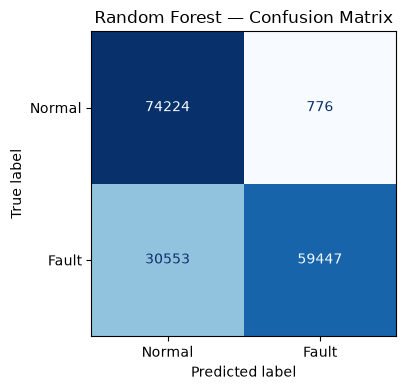

In [5]:
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred, display_labels=["Normal", "Fault"],
    cmap="Blues", colorbar=False, ax=ax)
ax.set_title("Random Forest — Confusion Matrix")
plt.tight_layout(); plt.savefig("figures/rf_confusion_matrix.png", bbox_inches="tight"); plt.show()

## 4 · Baseline Comparison Summary

Side-by-side comparison table and combined confusion matrix figure — this is the exact
evidence referenced in Section 4 of the Mid-Review Progress Report.

In [6]:
results = pd.DataFrame([iso_metrics, rf_metrics],
                       index=["Isolation Forest", "Random Forest"]).round(3)
results.insert(0, "Paradigm", ["Unsupervised", "Supervised"])
results.to_csv("figures/baseline_results.csv")
results

,Paradigm,Precision,Recall,F1,ROC-AUC
Isolation Forest,Unsupervised,0.966,0.394,0.559,0.764
Random Forest,Supervised,0.987,0.661,0.791,0.867


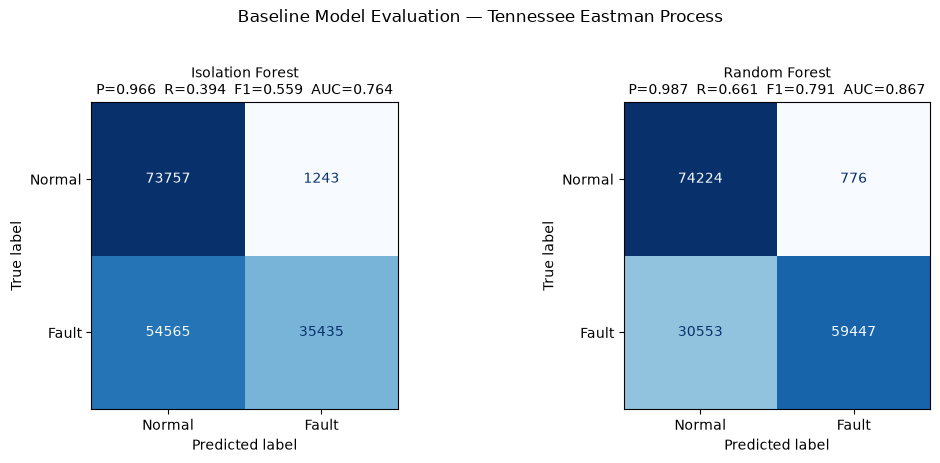


Saved: figures/baseline_confusion_matrices.png — use this as your Mid-Review screenshot.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test, iso_pred, display_labels=["Normal","Fault"],
    cmap="Blues", colorbar=False, ax=axes[0])
axes[0].set_title(f"Isolation Forest\nP={iso_metrics['Precision']:.3f}  R={iso_metrics['Recall']:.3f}  "
                   f"F1={iso_metrics['F1']:.3f}  AUC={iso_metrics['ROC-AUC']:.3f}", fontsize=10)

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred, display_labels=["Normal","Fault"],
    cmap="Blues", colorbar=False, ax=axes[1])
axes[1].set_title(f"Random Forest\nP={rf_metrics['Precision']:.3f}  R={rf_metrics['Recall']:.3f}  "
                   f"F1={rf_metrics['F1']:.3f}  AUC={rf_metrics['ROC-AUC']:.3f}", fontsize=10)

fig.suptitle("Baseline Model Evaluation — Tennessee Eastman Process", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("figures/baseline_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved: figures/baseline_confusion_matrices.png — use this as your Mid-Review screenshot.")